# 08 - Inspecting a PIXELAV hand-off package before you ship it

**Scope.** This notebook is a *validation pass* over a hand-off package that has
**already been produced** by the pipeline. It loads the per-crossing records and the
PIXELAV deck for one sample and checks that the deck is internally consistent and
physically sensible, so a collaborator can trust it before feeding it to PIXELAV.

This is deliberately *not* a method notebook. How the crossings are obtained (reading
the silicon out as a Geant4 tracker), the local-frame definition, and the deck-column
spec are all derived in **`06_sensor_crossings_tracker.ipynb`** (sections 1–7) and `docs/pixelav_reference.md` §3b.
We do not repeat that here - we treat the package as a given artifact and audit it.

**What a package is.** `sim/make_pixelav_inputs.sh` (recipe: `docs/pixelav_reference.md`)
runs the tracker-SD sim, `extract_trackermom.py`, then `analysis/pixelav_converter.py`,
emitting per sample:

- `<prefix>.npz` - MCParticle cascade + tracker-hit arrays (the raw extraction)
- `<prefix>.json` / `.csv` - the per-crossing records (16 fields each, from `build_segments_C`)
- `<prefix>.pixelav.txt` - the PIXELAV deck (7-column `badeaa3` layout) + `.columns.txt` legend

The default sample below is a single pi+ at 50 GeV. A 50 GeV pi+ in an EM calorimeter is
mostly a minimum-ionizing punch-through track: it should cross most of the ~30 silicon
layers nearly straight (small cot, momentum barely softening with depth), with a handful
of low-energy electron secondaries from the developing shower. That expectation is what
the checks below test against.


## 1. Configuration

Everything that selects a sample lives here. Point `PREFIX` at any package produced by
`make_pixelav_inputs.sh` (drop the file extensions) and re-run the notebook; nothing
downstream hard-codes the pi+ sample.


In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt

# --- sample selection (the only thing you edit to inspect a different package) ---
REPO     = os.path.abspath(os.path.join(os.getcwd(), ".."))          # notebooks/ -> repo root
MODELS   = os.path.join(REPO, "models")
SAMPLE   = "pixelav_segments_piplus50_1evt"   # <prefix> of the produced package
PREFIX   = os.path.join(MODELS, SAMPLE)

JSON_PATH    = PREFIX + ".json"
CSV_PATH     = PREFIX + ".csv"
DECK_PATH    = PREFIX + ".pixelav.txt"
COLUMNS_PATH = DECK_PATH + ".columns.txt"

# Companion .npz (MCParticle cascade + tracker hits) is named for the sim sample, not the
# converter prefix. Tweak here if your package uses a different raw-extraction name.
NPZ_PATH = os.path.join(MODELS, "trackermom_piplus50_1evt.npz")

# A label describing the primary, used only for prose in the checks below.
PRIMARY_LABEL = "pi+ at 50 GeV (1 event)"

for p in (JSON_PATH, DECK_PATH, COLUMNS_PATH):
    print(("OK   " if os.path.exists(p) else "MISS ") + p)
print(("OK   " if os.path.exists(NPZ_PATH) else "MISS ") + NPZ_PATH + "  (optional companion)")


OK   /nashome/m/murtazas/CALOMAPS-rework-branch/models/pixelav_segments_piplus50_1evt.json
OK   /nashome/m/murtazas/CALOMAPS-rework-branch/models/pixelav_segments_piplus50_1evt.pixelav.txt
OK   /nashome/m/murtazas/CALOMAPS-rework-branch/models/pixelav_segments_piplus50_1evt.pixelav.txt.columns.txt
OK   /nashome/m/murtazas/CALOMAPS-rework-branch/models/trackermom_piplus50_1evt.npz  (optional companion)


## 2. Load the package and the converter's own constants

We import the converter module so the checks reuse its *actual* constants and helpers
(`LENGTH_UNIT_MM`, `ppion_betagamma_matched`, the grazing cut). Reusing the source of
truth - rather than re-typing numbers - is what makes this an audit rather than a
parallel re-implementation that could silently disagree.


In [2]:
import sys
sys.path.insert(0, os.path.join(REPO, "analysis"))
import pixelav_converter as pc

records = json.load(open(JSON_PATH))
print("loaded %d per-crossing records" % len(records))

# The 16 record fields, taken from the data itself (not hard-coded).
fields = list(records[0].keys())
print("record fields (%d):" % len(fields))
print("  " + ", ".join(fields))

# Converter constants the deck depends on.
print("converter LENGTH_UNIT_MM =", pc.LENGTH_UNIT_MM, "(mm -> microns factor for deck lengths)")
print("converter M_PION_GeV     =", pc.M_PION_GEV)


loaded 35 per-crossing records
record fields (16):
  track_id, layer_id, pdg, p_GeV, entry_u, entry_v, cot_alpha, cot_beta, flipped, sensor_normal_phi, depth_w_mm, energy_dep_GeV, n_steps, time_ns, variant, flags
converter LENGTH_UNIT_MM = 1000.0 (mm -> microns factor for deck lengths)
converter M_PION_GeV     = 0.13957


In [3]:
# Read the deck (7 whitespace-separated columns) and its legend.
deck = np.loadtxt(DECK_PATH)
if deck.ndim == 1:                      # guard: a single-line deck loads as 1-D
    deck = deck.reshape(1, -1)
deck_cols = ["cot_alpha", "cot_beta", "ppion", "flipped", "modx", "mody", "pT"]
print("deck shape:", deck.shape, "(rows = crossings written, cols = %d)" % len(deck_cols))
print()
print("legend file (.columns.txt):")
print(open(COLUMNS_PATH).read().rstrip())


deck shape: (35, 7) (rows = crossings written, cols = 7)

legend file (.columns.txt):
# PIXELAV track-list (badeaa3); lengths in microns; entry point is a LABEL (stock PIXELAV randomizes impact -- see docs/pixelav_reference.md)
cot_alpha cot_beta ppion flipped modx[um]=v_entry mody[um]=u_entry pT


## 3. Field and column inventory

Before trusting any value we confirm the package has exactly the fields the converter
promises - no missing fields, no surprise extras - and that the deck has the 7
`badeaa3` columns. Every field a downstream tool reads must actually be present.


In [4]:
# Expected 16 record fields, read straight off the converter's _record() return.
expected_fields = ["track_id", "layer_id", "pdg", "p_GeV", "entry_u", "entry_v",
                   "cot_alpha", "cot_beta", "flipped", "sensor_normal_phi",
                   "depth_w_mm", "energy_dep_GeV", "n_steps", "time_ns",
                   "variant", "flags"]

missing = [f for f in expected_fields if f not in fields]
extra   = [f for f in fields if f not in expected_fields]
print("record fields present:", len(fields), "/ expected", len(expected_fields))
print("  missing:", missing if missing else "none")
print("  extra  :", extra if extra else "none")

# Deck width must be 7 for the badeaa3 layout.
print("deck width:", deck.shape[1], "(expected 7 for badeaa3)")
assert not missing, "package is missing required record fields: %s" % missing
assert deck.shape[1] == 7, "deck is not 7-column badeaa3"
print()
print("OK: record fields and deck width match the converter spec.")


record fields present: 16 / expected 16
  missing: none
  extra  : none
deck width: 7 (expected 7 for badeaa3)

OK: record fields and deck width match the converter spec.


## 4. Deck rows trace back to records (axis swap + microns)

The deck is a projection of the records. Each non-grazing record becomes one deck line,
with the entry point converted mm -> microns and the two transverse axes swapped:

- `modx` (deck col 5) = `entry_v` x `LENGTH_UNIT_MM`   (the cylinder-z axis)
- `mody` (deck col 6) = `entry_u` x `LENGTH_UNIT_MM`   (the across-pitch axis)

(The swap is PIXELAV's pixel geometry: its 21-pixel axis runs along barrel-z = our `v`,
its 13-pixel axis across the pitch = our `u`. Full rationale: notebook 06 §7 + pixelav_reference.md §3b.)

We also confirm the grazing accounting: the converter skips any crossing with non-finite
or `|cot| > 10` direction cosines, exactly as PIXELAV does, so

    deck rows  ==  records  -  grazing-skipped records.


In [5]:
U = pc.LENGTH_UNIT_MM   # 1000.0; mm -> microns

# Re-derive which records the converter would write (its exact grazing rule).
def is_grazing(r):
    ca, cb = r["cot_alpha"], r["cot_beta"]
    return (not (np.isfinite(ca) and np.isfinite(cb))) or abs(ca) > 10.0 or abs(cb) > 10.0

kept = [r for r in records if not is_grazing(r)]
n_grazing = len(records) - len(kept)
print("records: %d total, %d grazing-skipped (|cot|>10 or non-finite), %d kept"
      % (len(records), n_grazing, len(kept)))
print("deck rows:", deck.shape[0])
assert deck.shape[0] == len(kept), "deck row count != kept records (grazing accounting off)"

# Spot-check the axis swap + unit on every kept row.
worst = 0.0
for i, r in enumerate(kept):
    exp_modx = r["entry_v"] * U      # col 5 <- entry_v
    exp_mody = r["entry_u"] * U      # col 6 <- entry_u
    worst = max(worst, abs(deck[i, 4] - exp_modx), abs(deck[i, 5] - exp_mody))
print("max |deck modx/mody - expected| over all rows: %.3e microns (deck is %.4f-rounded)" % (worst, worst))
assert worst < 1e-3, "axis-swap / micron mapping mismatch"
print()
print("OK: modx<-entry_v, mody<-entry_u, lengths in microns; grazing accounting consistent.")


records: 35 total, 0 grazing-skipped (|cot|>10 or non-finite), 35 kept
deck rows: 35
max |deck modx/mody - expected| over all rows: 4.970e-05 microns (deck is 0.0000-rounded)

OK: modx<-entry_v, mody<-entry_u, lengths in microns; grazing accounting consistent.


## 5. ppion is the betagamma-matched pion momentum

PIXELAV models every track as a pion for dE/dx, so the converter hands it the pion
momentum with the *same* betagamma as our particle: `ppion = p x (m_pion / m_particle)`.
The driving consequence to verify:

- **Pions** (`|pdg| = 211`): the mass ratio is 1, so `ppion == pT == p_GeV` (identity).
- **Electrons** (`|pdg| = 11`): `m_pion / m_e ~ 273`, so `ppion ~ 273 x pT`. A soft shower
  electron handed its raw momentum would be mistaken for a slow pion and hugely
  over-ionize via the 1/beta^2 rise; the rescale fixes that.

We recompute `ppion` from each record with the converter's own helper and compare it to
the deck's column 3.


In [6]:
# (1) deck column 3 must match the converter helper recomputed from the unrounded records.
ppion_recomputed = np.array([pc.ppion_betagamma_matched(r["p_GeV"], r["pdg"]) for r in kept])
ppion_deck = deck[:, 2]
print("max |deck ppion - converter ppion|: %.3e GeV  (deck columns are %%.6f-rounded)"
      % np.max(np.abs(ppion_deck - ppion_recomputed)))

pdg = np.array([r["pdg"] for r in kept])
p_rec = np.array([r["p_GeV"] for r in kept])                # unrounded |p| from the records
# Exact ppion/p ratio = m_pion / m_particle, recomputed (not from the %.6f deck columns, whose
# rounding inflates the ratio for the tiny electron momenta ~1 MeV).
ratio_exact = np.divide(ppion_recomputed, p_rec,
                        out=np.full_like(ppion_recomputed, np.nan), where=p_rec != 0)
# Display ratio from the deck's own rounded columns, for the reader (scatter from rounding is expected).
ratio_deck = np.divide(ppion_deck, deck[:, 6],
                       out=np.full_like(ppion_deck, np.nan), where=deck[:, 6] != 0)

is_pi = np.abs(pdg) == 211
is_e  = np.abs(pdg) == 11
r_e = pc.M_PION_GEV / pc._MASS_GEV[11]
print()
print("pions (|pdg|=211):     %d rows; deck ppion/pT in [%.4f, %.4f] (expect ~1.0)"
      % (is_pi.sum(), np.nanmin(ratio_deck[is_pi]) if is_pi.any() else np.nan,
         np.nanmax(ratio_deck[is_pi]) if is_pi.any() else np.nan))
if is_e.any():
    print("electrons (|pdg|=11):  %d rows; deck ppion/pT in [%.2f, %.2f] (expect ~%.2f; %%.6f"
          " rounding widens this for ~MeV electrons)"
          % (is_e.sum(), np.nanmin(ratio_deck[is_e]), np.nanmax(ratio_deck[is_e]), r_e))
    print("  m_pion/m_e =", r_e)
else:
    print("no electron crossings in this sample")

# Assert on the exact (unrounded) ratio, which is rounding-independent.
if is_pi.any():
    assert np.allclose(ratio_exact[is_pi], 1.0, atol=1e-9), "pion ppion != p"
if is_e.any():
    assert np.allclose(ratio_exact[is_e], r_e, rtol=1e-6), "electron rescale off"
print()
print("OK: ppion is betagamma-matched (identity for pions, ~273x for electrons).")


max |deck ppion - converter ppion|: 4.949e-07 GeV  (deck columns are %.6f-rounded)

pions (|pdg|=211):     30 rows; deck ppion/pT in [1.0000, 1.0000] (expect ~1.0)
electrons (|pdg|=11):  5 rows; deck ppion/pT in [273.09, 273.22] (expect ~273.13; %.6f rounding widens this for ~MeV electrons)
  m_pion/m_e = 273.13164996408995

OK: ppion is betagamma-matched (identity for pions, ~273x for electrons).


## 6. Does the sample look like the physics?

For a 50 GeV pi+ punching through the calorimeter we expect: most crossings are the
primary pion at ~50 GeV; direction cosines are small (near-normal incidence) and none
grazing (the converter would have dropped those); the primary's momentum softens only
slightly with depth; and any electrons are soft shower secondaries appearing deeper in.


In [7]:
from collections import Counter
pdg_all = np.array([r["pdg"] for r in records])
print("species breakdown (PDG -> count):")
for code_, n in sorted(Counter(pdg_all.tolist()).items(), key=lambda kv: -kv[1]):
    name = {211: "pi+", -211: "pi-", 11: "e-", -11: "e+", 13: "mu-", -13: "mu+"}.get(code_, str(code_))
    print("  %-5s (%5d): %d" % (name, code_, n))

p_all = np.array([r["p_GeV"] for r in records])
ca_all = np.array([r["cot_alpha"] for r in records])
cb_all = np.array([r["cot_beta"] for r in records])
lay_all = np.array([r["layer_id"] for r in records])

print()
print("momentum p_GeV: min %.4g, max %.4g" % (p_all.min(), p_all.max()))
print("layers spanned: %d .. %d (out of 0..29)" % (lay_all.min(), lay_all.max()))
n_graze = int((np.abs(ca_all) > 10.0).sum() + (np.abs(cb_all) > 10.0).sum())
print("|cot_alpha| max %.3f, |cot_beta| max %.3f (grazing cut is 10; %d grazing record(s) "
      "kept in the .json/.csv, dropped only from the deck)"
      % (np.abs(ca_all).max(), np.abs(cb_all).max(), n_graze))
# the DECK is what PIXELAV reads -- it must contain no grazing track
assert np.abs(deck[:, :2]).max() <= 10.0, "a grazing crossing leaked into the deck"


species breakdown (PDG -> count):
  pi+   (  211): 30
  e-    (   11): 3
  e+    (  -11): 2

momentum p_GeV: min 0.00111, max 49.99
layers spanned: 0 .. 29 (out of 0..29)
|cot_alpha| max 0.647, |cot_beta| max 1.089 (grazing cut is 10; 0 grazing record(s) kept in the .json/.csv, dropped only from the deck)


In [8]:
# Primary = the most common track_id (the punch-through pion).
tid_all = np.array([r["track_id"] for r in records])
primary_tid = Counter(tid_all.tolist()).most_common(1)[0][0]
prim = sorted([r for r in records if r["track_id"] == primary_tid], key=lambda r: r["layer_id"])
prim_lay = np.array([r["layer_id"] for r in prim])
prim_p   = np.array([r["p_GeV"] for r in prim])
print("primary track_id=%d (%s): %d crossings, layers %d..%d"
      % (primary_tid, PRIMARY_LABEL, len(prim), prim_lay.min(), prim_lay.max()))
print("primary momentum: entry %.3f GeV -> exit %.3f GeV (softens with depth)"
      % (prim_p[0], prim_p[-1]))


primary track_id=0 (pi+ at 50 GeV (1 event)): 30 crossings, layers 0..29
primary momentum: entry 49.994 GeV -> exit 49.655 GeV (softens with depth)


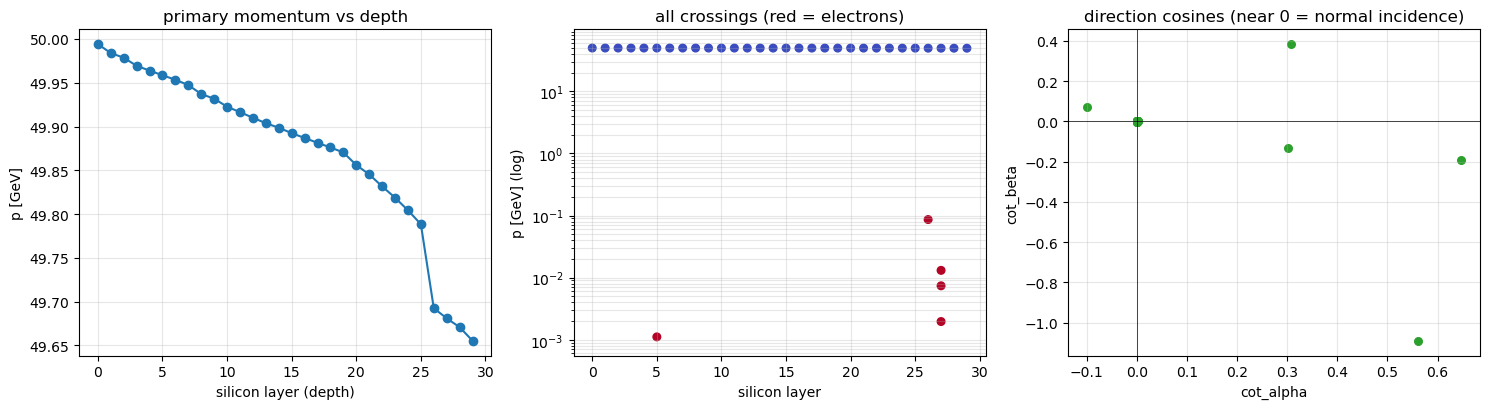

In [9]:
# Three diagnostic panels. Momentum spans many decades (50 GeV primary vs MeV electrons),
# so we use a log y-axis - guard it against any non-positive entry first.
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) primary momentum vs depth
ax[0].plot(prim_lay, prim_p, "o-", color="C0")
ax[0].set_xlabel("silicon layer (depth)"); ax[0].set_ylabel("p [GeV]")
ax[0].set_title("primary momentum vs depth")
ax[0].grid(alpha=0.3)

# (b) per-crossing momentum, all species, log scale (guarded)
mask_pos = p_all > 0
pos = p_all[mask_pos]
if pos.size:
    lo = max(pos.min() * 0.5, 1e-6)
    ax[1].scatter(lay_all[mask_pos], pos, c=(np.abs(pdg_all[mask_pos]) == 11),
                  cmap="coolwarm", s=30)
    ax[1].set_yscale("log"); ax[1].set_ylim(lo, p_all.max() * 2)
else:
    ax[1].text(0.5, 0.5, "no positive momenta", ha="center", transform=ax[1].transAxes)
ax[1].set_xlabel("silicon layer"); ax[1].set_ylabel("p [GeV] (log)")
ax[1].set_title("all crossings (red = electrons)")
ax[1].grid(alpha=0.3, which="both")

# (c) direction cosines - should cluster near zero (near-normal incidence)
ax[2].scatter(ca_all, cb_all, s=30, color="C2")
ax[2].axhline(0, color="k", lw=0.5); ax[2].axvline(0, color="k", lw=0.5)
ax[2].set_xlabel("cot_alpha"); ax[2].set_ylabel("cot_beta")
ax[2].set_title("direction cosines (near 0 = normal incidence)")
ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 6b. Justify every column, one plot at a time

The checks above proved the deck is *internally consistent*. These panels show it is
*physically sensible* - one diagnostic per deck column / record field, building from the
momentum spectrum up to the per-sensor occupancy. Everything is derived from `records`
(the per-crossing list) and the converter helpers in `pc`, so it works for any package you
load in section 1 (a punch-through pi+ here; a gamma package will populate the tails more).


In [10]:
import numpy as np
# Robust per-crossing arrays straight from the records (missing fields -> NaN, so a plot
# never crashes on a package that lacks one).
def _col(key):
    return np.array([r.get(key, np.nan) for r in records], dtype=float)
p_GeV  = _col("p_GeV")
pdg    = np.array([r.get("pdg", 0) for r in records])
ca     = _col("cot_alpha"); cb = _col("cot_beta")
lay    = _col("layer_id")
eu     = _col("entry_u");   ev = _col("entry_v")
dep    = _col("energy_dep_GeV"); dw = _col("depth_w_mm")
nstep  = _col("n_steps");   tns = _col("time_ns"); flip = _col("flipped")
# ppion (betagamma-matched) recomputed from the unrounded momentum (rounding-independent)
ppion  = np.array([pc.ppion_betagamma_matched(r["p_GeV"], r["pdg"]) for r in records], float)
modx   = ev * pc.LENGTH_UNIT_MM   # deck col 5 (PIXELAV 21-px axis)
mody   = eu * pc.LENGTH_UNIT_MM   # deck col 6 (PIXELAV 13-px axis)
m_pi = np.abs(pdg) == 211; m_e = np.abs(pdg) == 11; m_other = ~(m_pi | m_e)
print("crossings: %d  (pi+/-: %d, e+/-: %d, other: %d)" % (len(records), m_pi.sum(), m_e.sum(), m_other.sum()))


crossings: 35  (pi+/-: 30, e+/-: 5, other: 0)


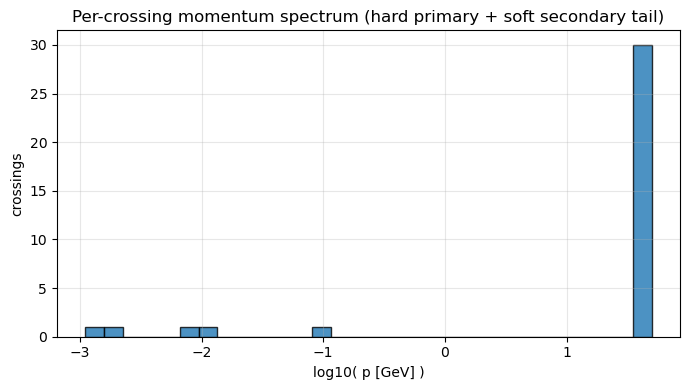

In [11]:
# (i) per-crossing momentum spectrum -- one hard primary near the beam energy, a soft
#     EM-secondary tail down to ~MeV. Log x so both ends are visible.
pos = p_GeV[p_GeV > 0]
fig, ax = plt.subplots(figsize=(7, 4))
if pos.size:
    ax.hist(np.log10(pos), bins=30, color="C0", edgecolor="k", alpha=0.8)
ax.set_xlabel("log10( p [GeV] )"); ax.set_ylabel("crossings")
ax.set_title("Per-crossing momentum spectrum (hard primary + soft secondary tail)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


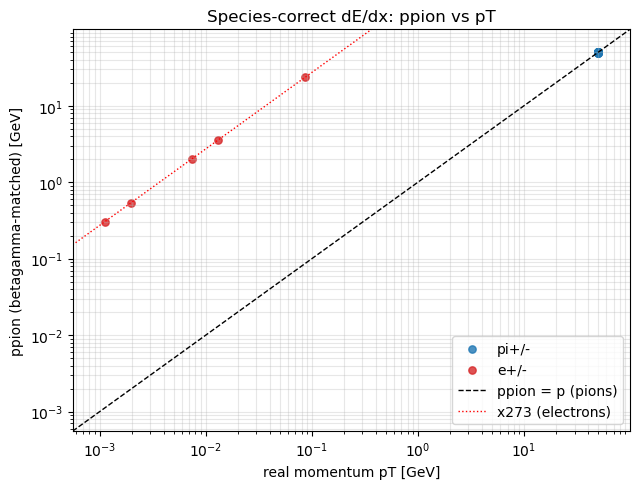

In [12]:
# (ii) ppion vs real momentum pT. PIXELAV uses a pion-only Bichsel dE/dx, so each track is
#      given ppion = p * (m_pi / m_particle): pions sit on the identity line; electrons land
#      ~273x higher (they are ~273x lighter) so PIXELAV reproduces their real ionisation.
ratio_e = pc.M_PION_GEV / pc._MASS_GEV[11]
fig, ax = plt.subplots(figsize=(6.5, 5))
for m, lab, col in [(m_pi, "pi+/-", "C0"), (m_e, "e+/-", "C3"), (m_other, "other", "0.5")]:
    if m.any(): ax.scatter(p_GeV[m], ppion[m], s=28, c=col, label=lab, alpha=0.8)
allv = np.concatenate([p_GeV[p_GeV > 0], ppion[ppion > 0]])
if allv.size:
    lo, hi = allv.min() * 0.5, allv.max() * 2; xs = np.array([lo, hi])
    ax.plot(xs, xs, "k--", lw=1, label="ppion = p (pions)")
    ax.plot(xs, xs * ratio_e, "r:", lw=1, label="x%.0f (electrons)" % ratio_e)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("real momentum pT [GeV]"); ax.set_ylabel("ppion (betagamma-matched) [GeV]")
ax.set_title("Species-correct dE/dx: ppion vs pT"); ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()


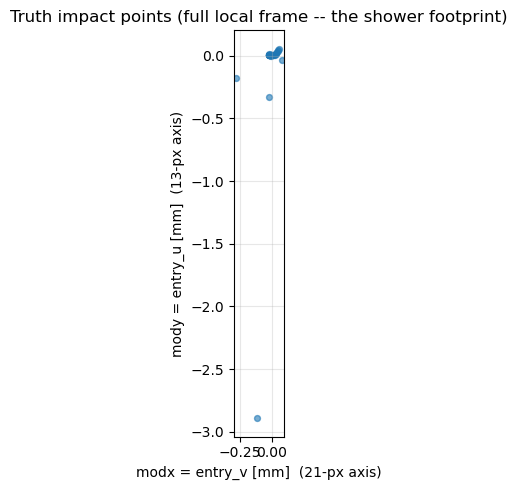

In [13]:
# (iii) truth mid-plane impact points (microns). modx<-entry_v (PIXELAV 21-px axis),
#       mody<-entry_u (13-px axis). These are the FULL local-frame impact coordinates (mm x 1000),
#       so they span the whole shower transverse footprint (tens of mm) -- NOT a single readout
#       window. The patched real-entry driver reduces each impact mod-pitch to the sub-pixel
#       position before transport; stock PIXELAV ignores it and randomises over the central 3x3.
fig, ax = plt.subplots(figsize=(6, 5))
gx = np.isfinite(modx) & np.isfinite(mody)
if gx.any():
    ax.scatter(modx[gx] / 1000.0, mody[gx] / 1000.0, s=18, c="C0", alpha=0.6)
ax.set_aspect("equal"); ax.grid(alpha=0.3)
ax.set_xlabel("modx = entry_v [mm]  (21-px axis)"); ax.set_ylabel("mody = entry_u [mm]  (13-px axis)")
ax.set_title("Truth impact points (full local frame -- the shower footprint)")
plt.tight_layout(); plt.show()


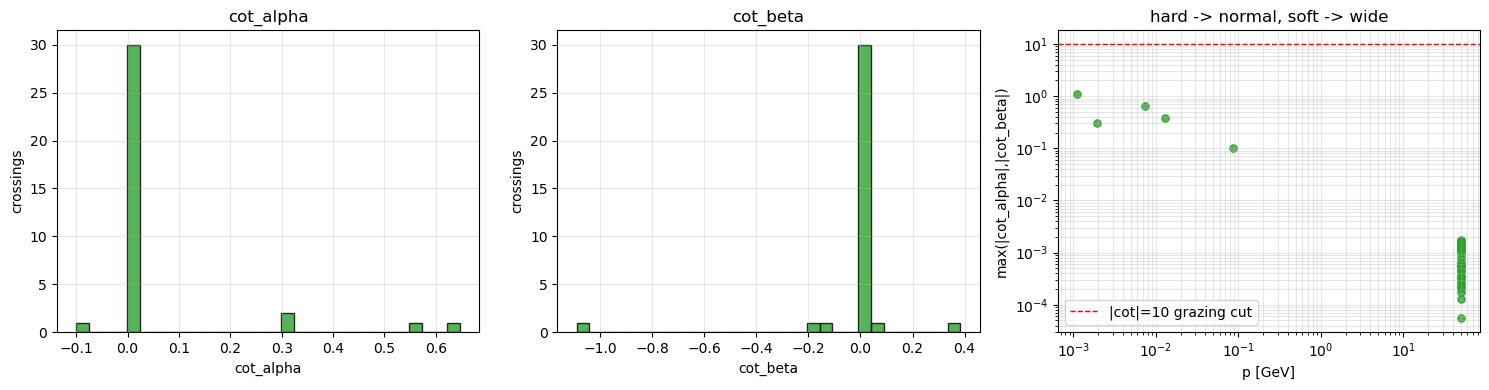

In [14]:
# (iv) direction cosines. cot_alpha/cot_beta cluster near 0 (near-normal incidence for a
#      +y beam); the wide ones are soft scattered secondaries. The converter drops |cot|>10
#      (grazing) -- shown as the guard band.
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, v, name in [(ax[0], ca, "cot_alpha"), (ax[1], cb, "cot_beta")]:
    vv = v[np.isfinite(v)]
    if vv.size: a.hist(np.clip(vv, -10, 10), bins=30, color="C2", edgecolor="k", alpha=0.8)
    a.set_xlabel(name); a.set_ylabel("crossings"); a.grid(alpha=0.3)
mc = np.nanmax(np.abs(np.vstack([ca, cb])), axis=0)
g = np.isfinite(mc) & (p_GeV > 0)
if g.any(): ax[2].scatter(p_GeV[g], mc[g], s=28, c="C2", alpha=0.8)
ax[2].axhline(10, color="r", ls="--", lw=1, label="|cot|=10 grazing cut")
ax[2].set_xscale("log"); ax[2].set_yscale("log")
ax[2].set_xlabel("p [GeV]"); ax[2].set_ylabel("max(|cot_alpha|,|cot_beta|)")
ax[2].set_title("hard -> normal, soft -> wide"); ax[2].legend(); ax[2].grid(alpha=0.3, which="both")
ax[0].set_title("cot_alpha"); ax[1].set_title("cot_beta")
plt.tight_layout(); plt.show()


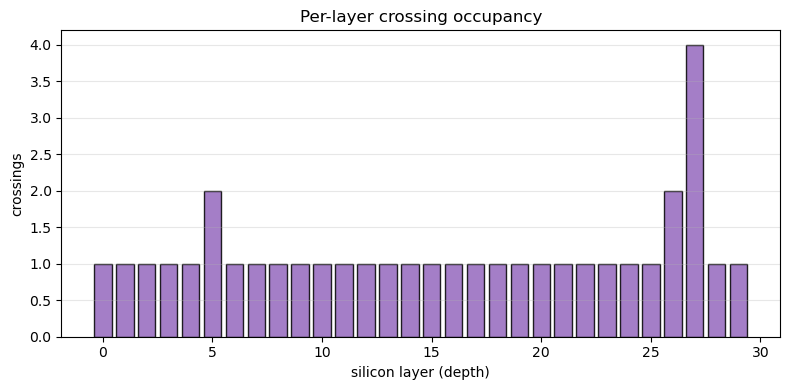

In [15]:
# (v) where in depth the crossings happen -- occupancy per silicon layer (0..29).
fig, ax = plt.subplots(figsize=(8, 4))
gl = np.isfinite(lay)
if gl.any():
    counts = np.bincount(lay[gl].astype(int), minlength=30)[:30]
    ax.bar(np.arange(30), counts, color="C4", edgecolor="k", alpha=0.85)
ax.set_xlabel("silicon layer (depth)"); ax.set_ylabel("crossings")
ax.set_title("Per-layer crossing occupancy"); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


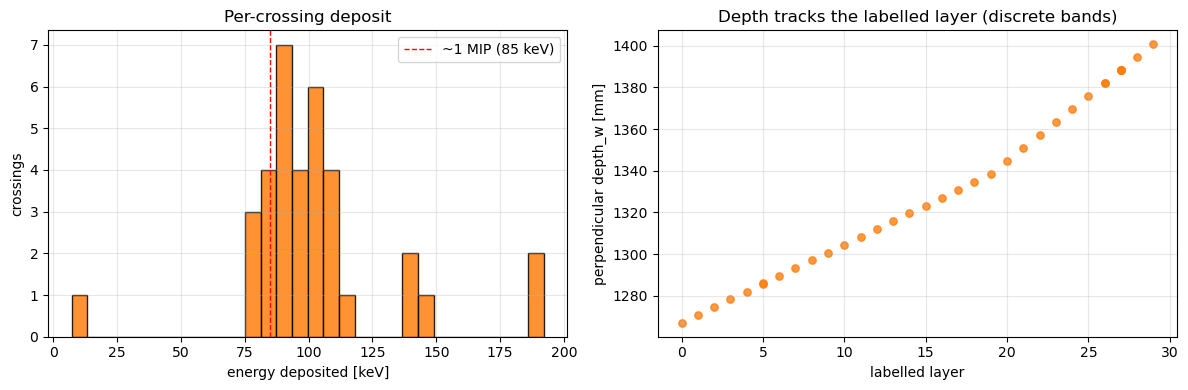

In [16]:
# (vi) energy deposited per crossing (a MIP ~ 85 keV in 320 um Si) and the crossing depth
#      vs its labelled layer -- each crossing should sit on its layer's discrete depth band.
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
dd = dep[np.isfinite(dep)] * 1e6  # keV
if dd.size:
    ax[0].hist(dd, bins=30, color="C1", edgecolor="k", alpha=0.85)
    ax[0].axvline(85, color="r", ls="--", lw=1, label="~1 MIP (85 keV)"); ax[0].legend()
ax[0].set_xlabel("energy deposited [keV]"); ax[0].set_ylabel("crossings")
ax[0].set_title("Per-crossing deposit"); ax[0].grid(alpha=0.3)
gd = np.isfinite(dw) & np.isfinite(lay)
if gd.any(): ax[1].scatter(lay[gd], dw[gd], s=28, c="C1", alpha=0.8)
ax[1].set_xlabel("labelled layer"); ax[1].set_ylabel("perpendicular depth_w [mm]")
ax[1].set_title("Depth tracks the labelled layer (discrete bands)"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


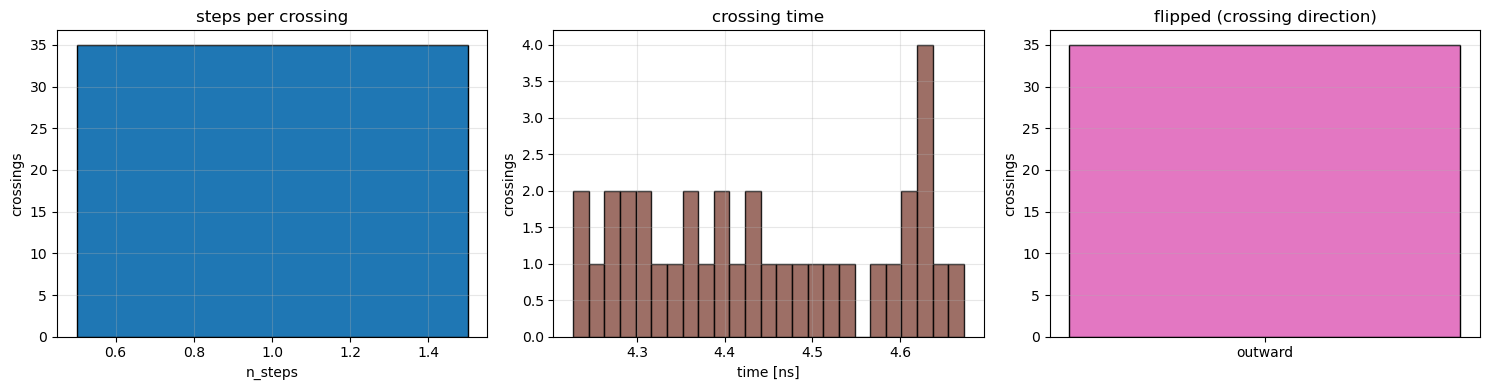

In [17]:
# (vii) bookkeeping columns: n_steps (1 per crossing for the tracker SD), crossing time,
#       and the inward/outward (flipped) split.
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ns = nstep[np.isfinite(nstep)]
if ns.size: ax[0].hist(ns, bins=range(int(ns.min()), int(ns.max()) + 2), color="C0", edgecolor="k", align="left")
ax[0].set_xlabel("n_steps"); ax[0].set_ylabel("crossings"); ax[0].set_title("steps per crossing"); ax[0].grid(alpha=0.3)
tt = tns[np.isfinite(tns)]
if tt.size: ax[1].hist(tt, bins=25, color="C5", edgecolor="k", alpha=0.85)
ax[1].set_xlabel("time [ns]"); ax[1].set_ylabel("crossings"); ax[1].set_title("crossing time"); ax[1].grid(alpha=0.3)
ff = flip[np.isfinite(flip)].astype(int)
if ff.size:
    vals, cnts = np.unique(ff, return_counts=True)
    ax[2].bar([{0: "inward", 1: "outward"}.get(v, str(v)) for v in vals], cnts, color="C6", edgecolor="k")
ax[2].set_ylabel("crossings"); ax[2].set_title("flipped (crossing direction)"); ax[2].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


## 7. Verdict

A summary line a collaborator can paste into a hand-off note. If every assertion above
passed and the species / momentum / direction picture matches the expected punch-through,
the deck is safe to feed to PIXELAV (Stage B). Stage-A sensor/field setup is independent
and not produced here.


In [18]:
print("PIXELAV hand-off package:", SAMPLE)
print("  primary:            ", PRIMARY_LABEL)
print("  records (crossings):", len(records))
print("  deck rows written:  ", deck.shape[0], "(grazing-skipped: %d)" % n_grazing)
print("  species:            ", dict(Counter(np.abs(pdg_all).tolist())))
print("  deck layout:         badeaa3 (7 col); lengths in microns; entry = mid-plane label")
print("  checks: fields OK, deck width OK, axis-swap+units OK, ppion betagamma-matched OK,")
print("          grazing accounting OK, no grazing survivor, momenta/directions sensible.")
print()
print("Ready to hand to PIXELAV Stage B. Method: notebook 06 sections 1-7; deck spec: pixelav_reference.md 3b;")
print("recipe: docs/pixelav_handoff.md (+ sim/make_pixelav_inputs.sh).")


PIXELAV hand-off package: pixelav_segments_piplus50_1evt
  primary:             pi+ at 50 GeV (1 event)
  records (crossings): 35
  deck rows written:   35 (grazing-skipped: 0)
  species:             {211: 30, 11: 5}
  deck layout:         badeaa3 (7 col); lengths in microns; entry = mid-plane label
  checks: fields OK, deck width OK, axis-swap+units OK, ppion betagamma-matched OK,
          grazing accounting OK, no grazing survivor, momenta/directions sensible.

Ready to hand to PIXELAV Stage B. Method: notebook 06 sections 1-7; deck spec: pixelav_reference.md 3b;
recipe: docs/pixelav_handoff.md (+ sim/make_pixelav_inputs.sh).
